In [2]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

def get_ecfp(smiles_list, radius=3, n_bits=2048):

    fps = []

    for i, smi in enumerate(smiles_list):
        if not isinstance(smi, str) or len(smi.strip()) == 0:
            print(f"[WARNING] Skipping invalid entry at index {i}: {repr(smi)}")
            fps.append(np.zeros(n_bits))
            continue
        
        mol = Chem.MolFromSmiles(smi)

        if mol is None:
            print(f"[WARNING] Invalid SMILES at index {i}: {smi}")
            fps.append(np.zeros(n_bits))
            continue

        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
        fps.append(fp)

    return np.array(fps)

def get_ecfp_counts(smiles_list, radius=3, n_bits=2048):

    fps = []

    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:

            fps.append(np.zeros(n_bits))
            continue

        fp = AllChem.GetHashedMorganFingerprint(mol, radius, nBits=n_bits)
        arr = np.zeros((n_bits,))

        for idx, count in fp.GetNonzeroElements().items():
            arr[idx % n_bits] = count

        fps.append(arr)

    return np.array(fps)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


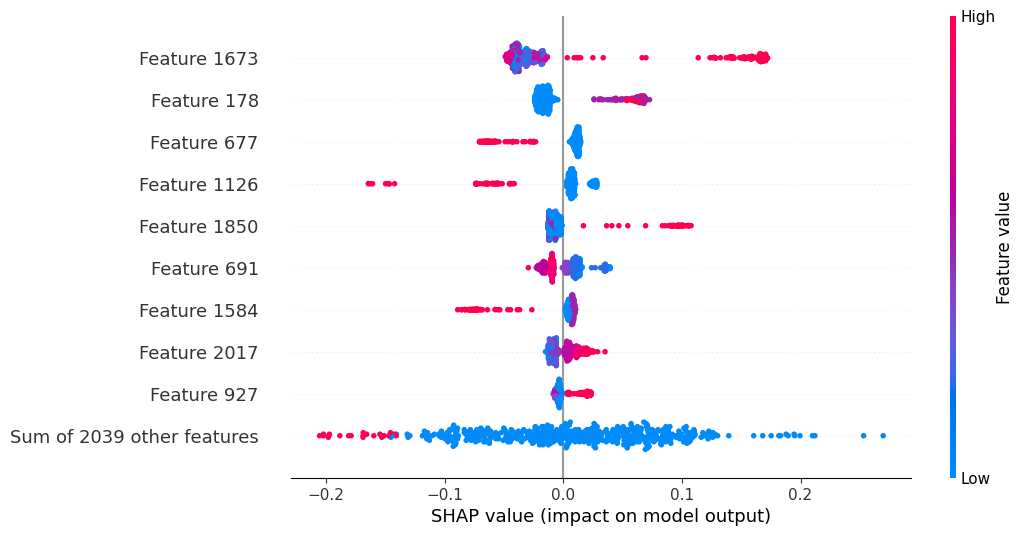

In [3]:
with open(r'M:\ML_scripts\github_files\tm60.pkl', 'rb') as m:
    model = pickle.load(m)

predictor = model.predictor
descriptor = model.descriptor

data = pd.read_csv(r'M:\ML_scripts\github_files\tm60-full-compiled-data.csv').drop(columns=['Unnamed: 0'])

train_smi = data[data['Set'] == 'train']['Structure']
test_smi = data[data['Set'] == 'test']['Structure']

X_desc = []

for x in train_smi:
    a = descriptor.calculate_from_smi(x)
    X_desc.append(np.array(a))

X_desc = np.array(X_desc)

explainer = shap.TreeExplainer(predictor, X_desc)
shap_values = explainer(X_desc)

shap_val = shap.Explanation(shap_values.values[:,:,1],
                            base_values=shap_values.base_values[:,1],
                            data=X_desc)

plt.figure(figsize=(18, 6))
shap.plots.beeswarm(shap_val, show=True, plot_size=(10, 6))

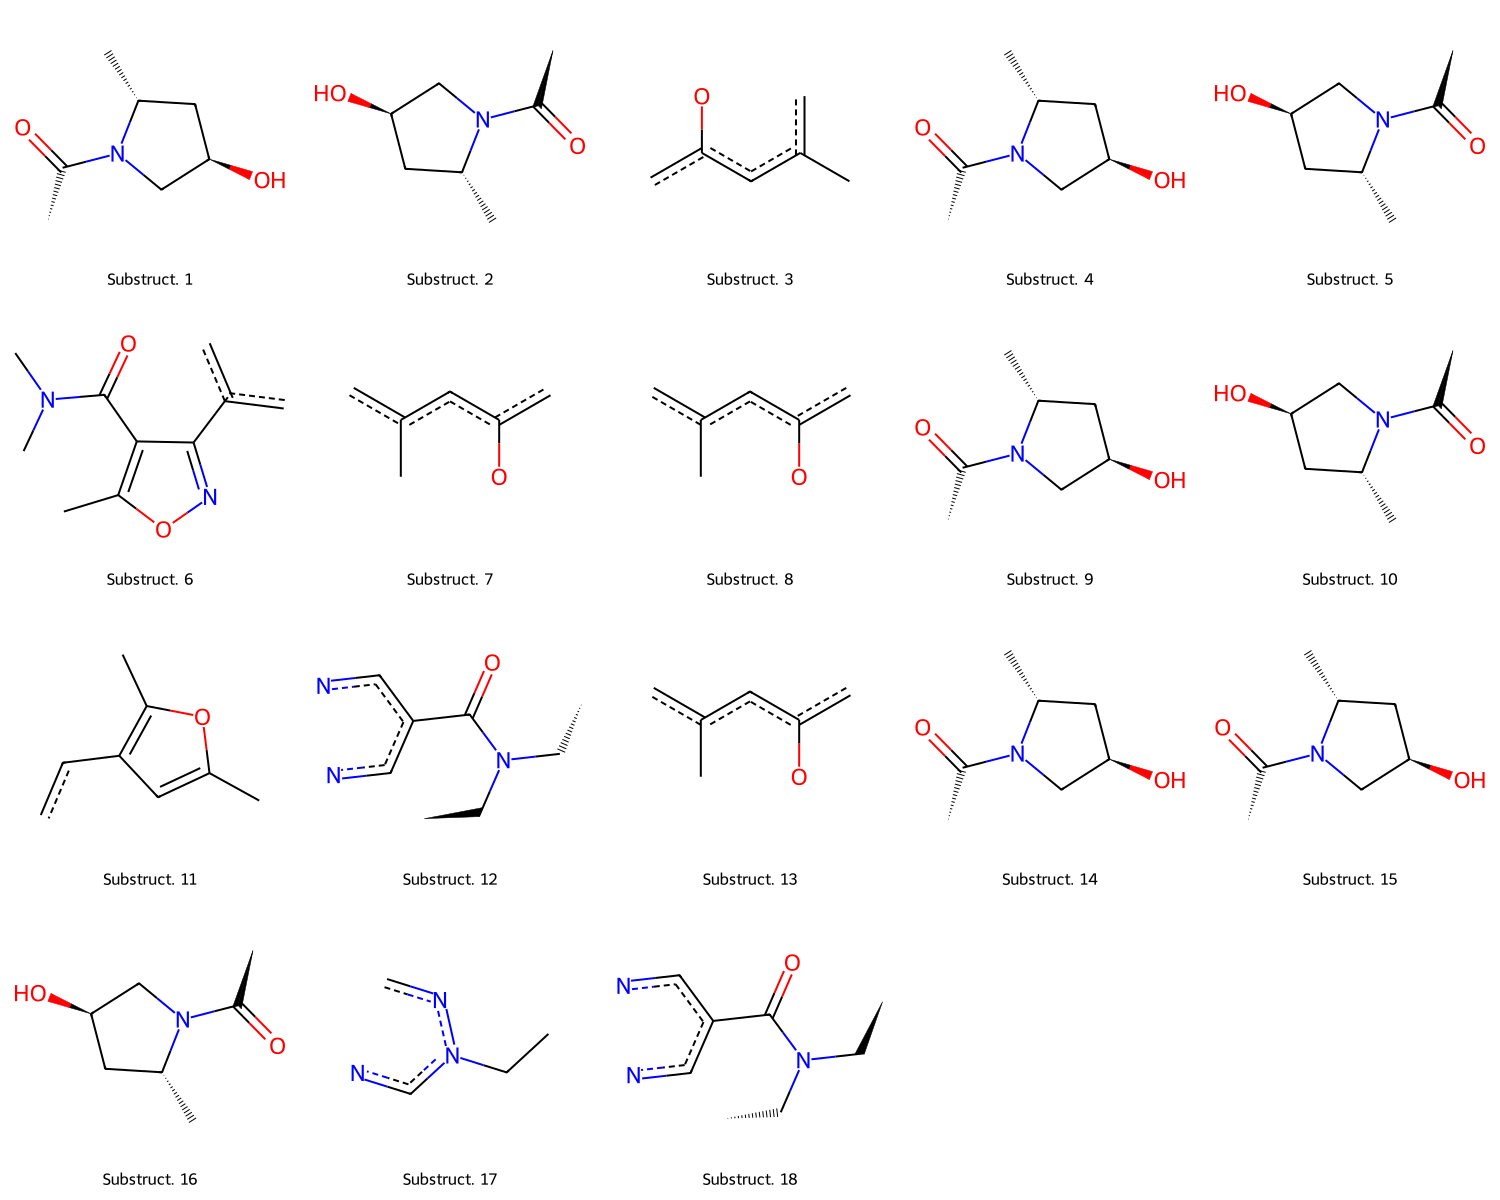

No. SMILES containing substructure: 18


In [6]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from IPython.display import display
import numpy as np


def get_ecfp_bit_substructures(smiles_list, bit_id, radius=3, nBits=2048, max_results=100000, show=True, show_substructures_grid=True):
    results = []

    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue

        bitInfo = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits, bitInfo=bitInfo)

        if bit_id in bitInfo:
            # Take first environment triggering this bit in this molecule
            atom_idx, rad = bitInfo[bit_id][0]
            env = AllChem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
            submol = Chem.PathToSubmol(mol, env)

            results.append((smi, mol, submol))

        if len(results) >= max_results:
            break

    if not results:
        print(f"No molecules found with bit {bit_id}.")
        return []

    if show:
        if show_substructures_grid:
            # Show grid of substructures only
            submols = [submol for _, _, submol in results]
            img = Draw.MolsToGridImage(
                submols,
                molsPerRow=5,
                subImgSize=(300, 300),
                legends=[f"Substruct. {i+1}" for i in range(len(submols))]
            )
            display(img)
        else:
            # Show full molecules with bit substructure highlighted
            mols = []
            highlights = []
            for smi, mol, submol in results:
                match = mol.GetSubstructMatch(submol)
                mols.append(mol)
                highlights.append(match)

            img = Draw.MolsToGridImage(
                mols,
                highlightAtomLists=highlights,
                molsPerRow=5,
                subImgSize=(400, 400),
                legends=[f"SMILES {i+1}" for i in range(len(mols))]
            )
            display(img)

    return results


bit_hits = get_ecfp_bit_substructures(train_smi.tolist(), bit_id=1673)
print(f'No. SMILES containing substructure: {len(bit_hits)}')